In [1]:
import sys; sys.path.append("../../"); sys.path.append("../../../.."); sys.path.append("../../../gmsh/"); sys.path.append("../../experiments/"); sys.path.append("../../../")
import experiment_helper
import igl
from periodic_simulation_setup import *
import json



In [2]:
a = 2
avg_len = 0.08
radius = 0.8

In [3]:
ih = 1.3
iw = 0.9
h = 5

In [4]:

# time = '2024_01_14_11_09'
# name = 'square_with_ellipse_hole_angle_height_1.6_width_1'


# time = '2024_01_17_09_06'
# name = 'square_with_ellipse_hole_angle_width_with_height_1.6'

time = '2024_01_17_11_33'
name = 'square_with_ellipse_hole_angle_width_height'
experiment_file = '../../experiments/parallelized_experiments/output/{}/{}/experiment_result.json'.format(name, time)
stiffness_path = '../../experiments/parallelized_experiments/output/{}/{}'.format(name, time)

In [5]:
import MeshFEM, visualization

In [6]:
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

In [7]:
angles = np.linspace(0, 45, 16)[2:]
widths = np.linspace(0.1, 0.9, 9)
heights = np.linspace(1.3, 1.8, 6)

In [8]:
label = "{:.2f}_{:.2f}_{:.2f}".format(angles[10], widths[3], heights[3])

In [9]:
label = '42.00_0.20_1.30'

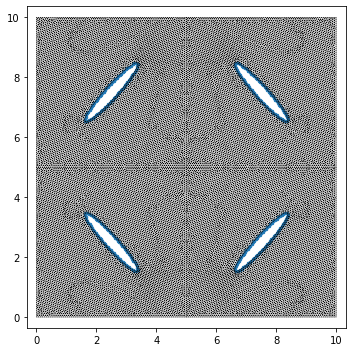

In [10]:
m = MeshFEM.mesh.Mesh('../../experiments/parallelized_experiments/output/{}/{}/{}/mesh_{}_{}.obj'.format(name, time, label, name, label))
fusing_vtx = np.load('../../experiments/parallelized_experiments/output/{}/{}/{}/fusedVtx_{}_{}.npy'.format(name, time, label, name, label))

visualization.plot_2d_mesh(m, pointList=fusing_vtx, width=5, height=5)


vertices = m.vertices()
vertices = np.concatenate((vertices, np.zeros((len(vertices), 1))), axis = 1)
m = MeshFEM.mesh.Mesh(vertices, m.elements())

finalMarkers = np.where(np.array(fusing_vtx) == 1)[0]
# m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, flip_orientation= 0)
# m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, axis = 1, flip_orientation= 1)

# m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, flip_orientation= 0)
# m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, axis = 1, flip_orientation= 1)

# m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, flip_orientation= 0)
# m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, axis = 1, flip_orientation= 1)

fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)

for vi in m.boundaryVertices():
    fusedVtx[vi] = True
    
isheet = inflation.InflatableSheet(m, fusedVtx = fusedVtx)

In [11]:
viewer = TriMeshViewer(isheet, width=500, height=500)
viewer.showWireframe(False)
viewer.update(scalarField=utils.getStrains(isheet)[:, 0])
viewer.show()

Renderer(camera=PerspectiveCamera(children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), quaternion=(…

In [22]:
name = "ellipse_2_color"

In [23]:
import tri_mesh_viewer

In [32]:
viewer = tri_mesh_viewer.TriMeshViewer(isheet, width = 1000, height = 1000)

In [33]:
# viewer = tri_mesh_viewer.OffscreenTriMeshViewer(isheet, width = 1000, height = 1000)

In [34]:
viewer.setCameraParams(((0, -4, 5),
 (0.0, 1, 0),
 (0.0, 0.0, 0.0)))

In [35]:
viewer.show()

Renderer(camera=PerspectiveCamera(children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), quaternion=(…

In [48]:
orender = viewer.offscreenRenderer(width=3000,height=3000)


In [49]:
orender.render()

In [50]:
orender.save("ellipse_many_without_wireframe.png")

In [38]:
orender.save("ellipse_many_with_wireframe.png")

In [39]:
# viewer.recordStart("{}_inflation.mp4".format(name), outWidth = 1000, outHeight = 1000, streaming = True)

In [51]:
viewer.showWireframe(True)


In [41]:
import experiment_helper

In [42]:
# pressure = 0.8
stiffness_pressure = 0.6
scale_factor_pressure = 0.01

In [43]:
allowBending = True
useTFT = True
disableFusedRegionTFT = False

In [44]:
def cb(i):
    # viewer.update(scalarField=utils.getStrains(isheet)[:, 0])
    viewer.update()

In [45]:
# ipu.setVars(np.load('parallel_tubes.npy'))

In [46]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = isheet.rigidMotionPinVars, 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6

isheet.setUseTensionFieldEnergy(useTFT)
isheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    isheet.disableFusedRegionTensionFieldTheory(False)
isheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 500
opts.gradTol = 1e-10
print(opts.factorizer)

cr = inflation.inflation_newton(isheet, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
# viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
viewer.update()
benchmark.report()

True 0.6 1e-06 []
CholeskyProvider.CatamariNesdis


KeyboardInterrupt: 

In [ ]:
viewer.recordStop()